# Imports

In [1]:
import pandas as pd
from qqman import qqman
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib_venn import venn2

# PCA Comparison

PC1 correlation: 1.000
PC2 correlation: -0.977
PC3 correlation: -0.970


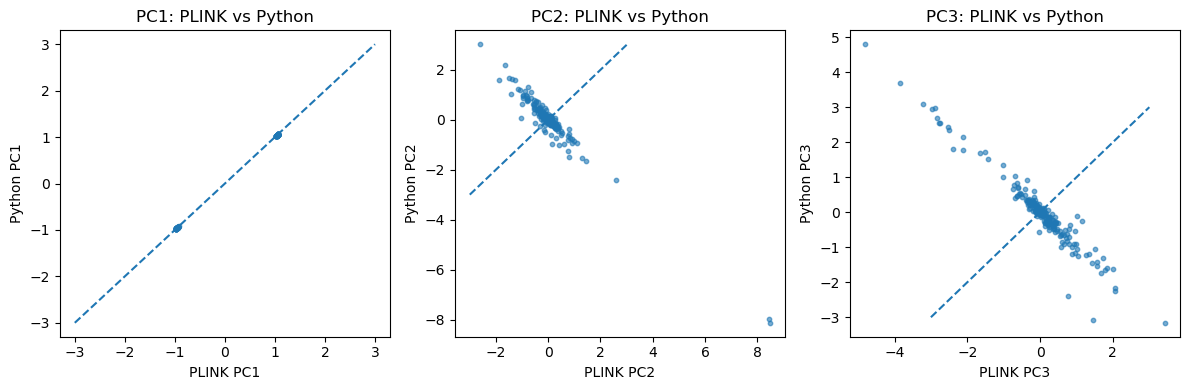

In [2]:
plink = np.loadtxt("../plink_results/ps3_gwas.eigenvec", usecols=[2,3,4])
gwas_py = np.loadtxt("../python_results/eigenvec.txt", usecols=[2,3,4])

def zscore(x):
    return (x - x.mean()) / x.std()

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i in range(3):
    x = zscore(plink[:,i])
    y = zscore(gwas_py[:,i])

    corr = np.corrcoef(x, y)[0,1]
    print(f"PC{i+1} correlation: {corr:.3f}") 

    axes[i].scatter(x, y, s=10, alpha=0.6)
    axes[i].set_title(f"PC{i+1}: PLINK vs Python")
    axes[i].set_xlabel(f"PLINK PC{i+1}")
    axes[i].set_ylabel(f"Python PC{i+1}")

    axes[i].plot([-3,3], [-3,3], linestyle="--")

plt.tight_layout()
plt.show()

# GWAS Comparisons

## No Covariance

### Plink GWAS Manhattan and QQ Plot

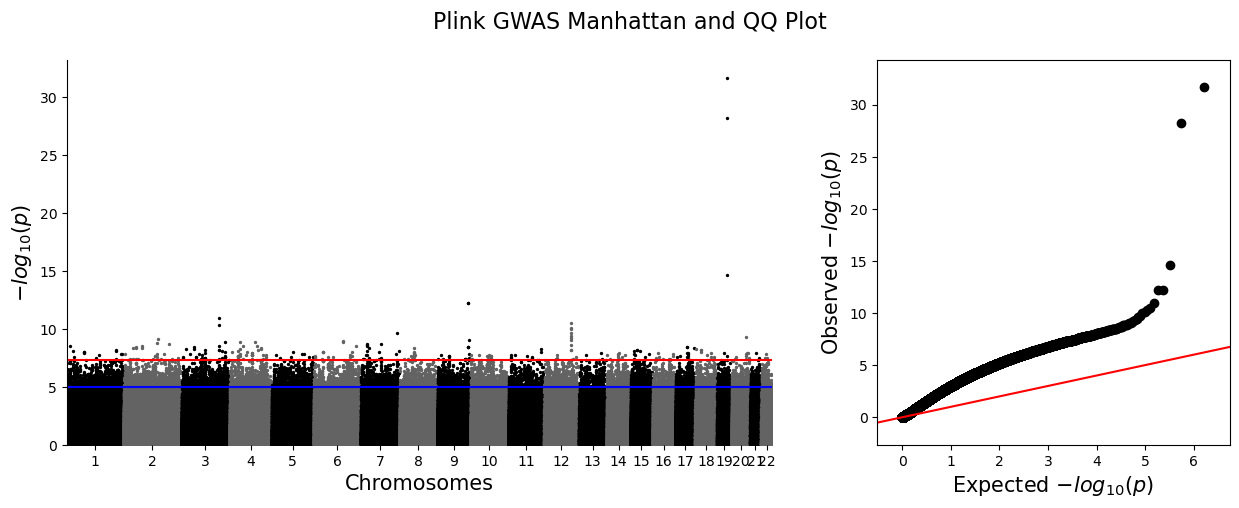

In [3]:
plink = pd.read_csv("../plink_results/ps3_gwas.assoc.linear", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("Plink GWAS Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(plink, ax=ax0)
qqman.qqplot(plink, ax=ax1)

### GWAS in Python Manhattan and QQ Plot

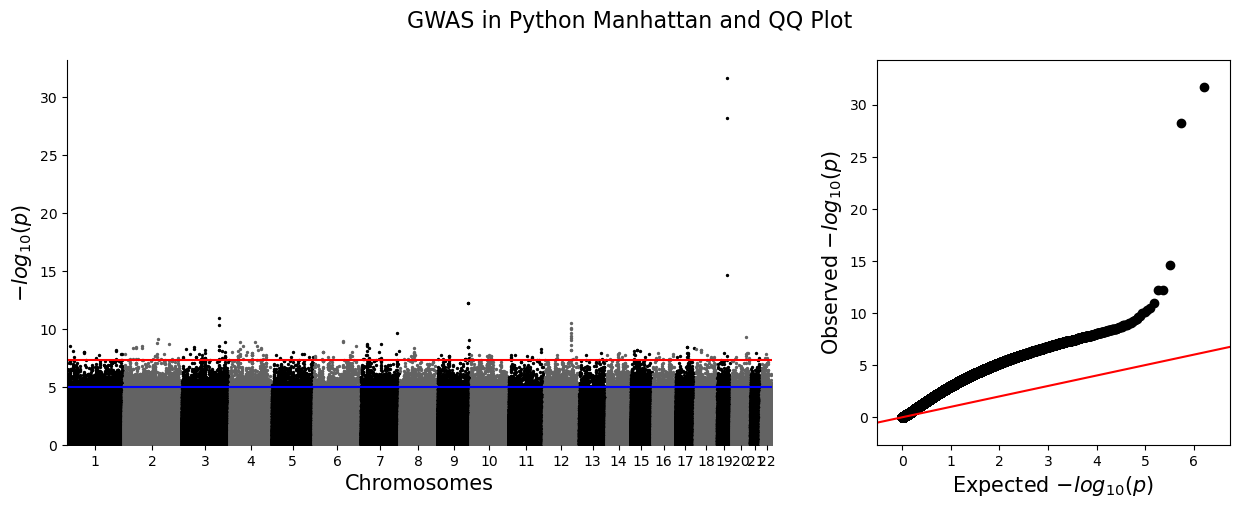

In [4]:
gwas_py = pd.read_csv("../python_results/gwas_results.tsv", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("GWAS in Python Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(gwas_py, ax=ax0)
qqman.qqplot(gwas_py, ax=ax1)

### Effect Size Comparison

Beta correlation: 1.000


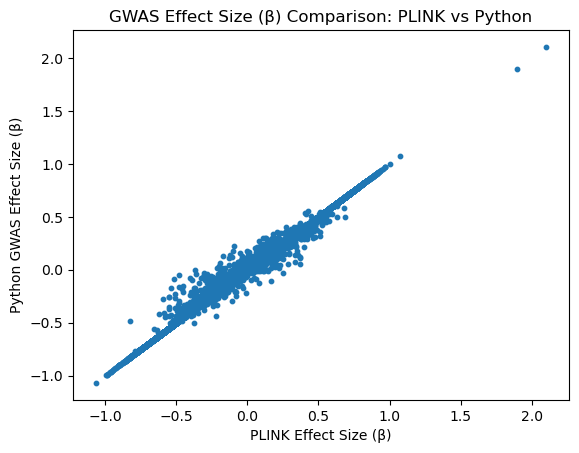

In [5]:
merged = plink.merge(gwas_py, on="SNP", suffixes=("_plink", "_gwas_py"))

corr = merged["BETA_plink"].corr(merged["BETA_gwas_py"])
print(f"Beta correlation: {corr:.3f}")

plt.scatter(merged["BETA_plink"], merged["BETA_gwas_py"], s=10)
plt.xlabel("PLINK Effect Size (β)")
plt.ylabel("Python GWAS Effect Size (β)")
plt.title("GWAS Effect Size (β) Comparison: PLINK vs Python")
plt.show()

### P-Value Comparison

P-value correlation: 1.000


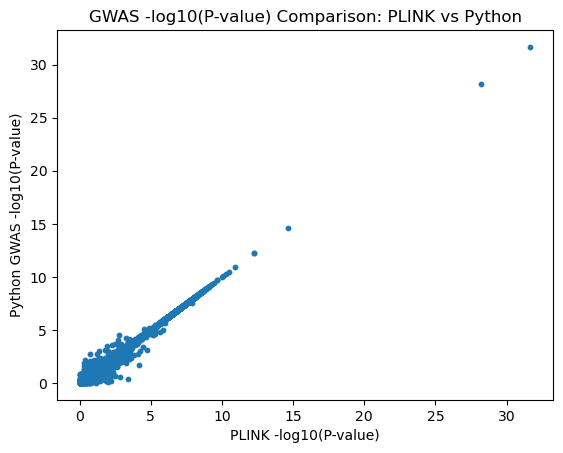

In [6]:
merged["logP_plink"] = -np.log10(merged["P_plink"])
merged["logP_gwas_py"] = -np.log10(merged["P_gwas_py"])

corr = merged["P_plink"].corr(merged["P_gwas_py"])
print(f"P-value correlation: {corr:.3f}")

plt.scatter(merged["logP_plink"], merged["logP_gwas_py"], s=10)
plt.xlabel("PLINK -log10(P-value)")
plt.ylabel("Python GWAS -log10(P-value)")
plt.title("GWAS -log10(P-value) Comparison: PLINK vs Python")
plt.show()

In [7]:
merged["rank_plink"] = merged["P_plink"].rank(method="min")
merged["rank_gwas_py"]  = merged["P_gwas_py"].rank(method="min")

merged[["rank_plink", "rank_gwas_py"]].corr()

top_plink = set(plink.nsmallest(10, "P")["SNP"])
top_gwas_py  = set(gwas_py.nsmallest(10, "P")["SNP"])

print("Overlap in Top 10:", len(top_plink & top_gwas_py))

Overlap in Top 10: 10


In [8]:
summary = merged[[
    "SNP",
    "BETA_plink", "BETA_gwas_py",
    "P_plink", "P_gwas_py",
    "rank_plink", "rank_gwas_py"
]].sort_values("rank_plink").head(20)

summary

,SNP,BETA_plink,BETA_gwas_py,P_plink,P_gwas_py,rank_plink,rank_gwas_py
302263,rs62117204,2.1050,2.104528,2.122000e-32,2.121923e-32,1.0,1.0
302266,rs4803750,1.8980,1.898317,6.102000e-29,6.102444e-29,2.0,2.0
302262,rs1531517,1.0010,1.000888,2.328000e-15,2.327750e-15,3.0,3.0
833752,rs2519093,-0.9908,-0.990820,5.676000e-13,5.675715e-13,4.0,4.0
833754,rs507666,-0.9908,-0.990820,5.676000e-13,5.675715e-13,4.0,4.0
537173,rs358702,-0.5654,-0.565360,1.204000e-11,1.204200e-11,6.0,6.0
120646,rs11113551,-0.7108,-0.710799,3.291000e-11,3.290831e-11,7.0,7.0
537180,rs7636224,-0.5419,-0.541872,4.915000e-11,4.915194e-11,8.0,8.0
120635,rs2374725,-0.7102,-0.710158,8.035000e-11,8.035379e-11,9.0,9.0
120637,rs11113515,-0.6867,-0.686743,1.027000e-10,1.027314e-10,10.0,10.0


## Covariance

### Plink GWAS Manhattan and QQ Plot

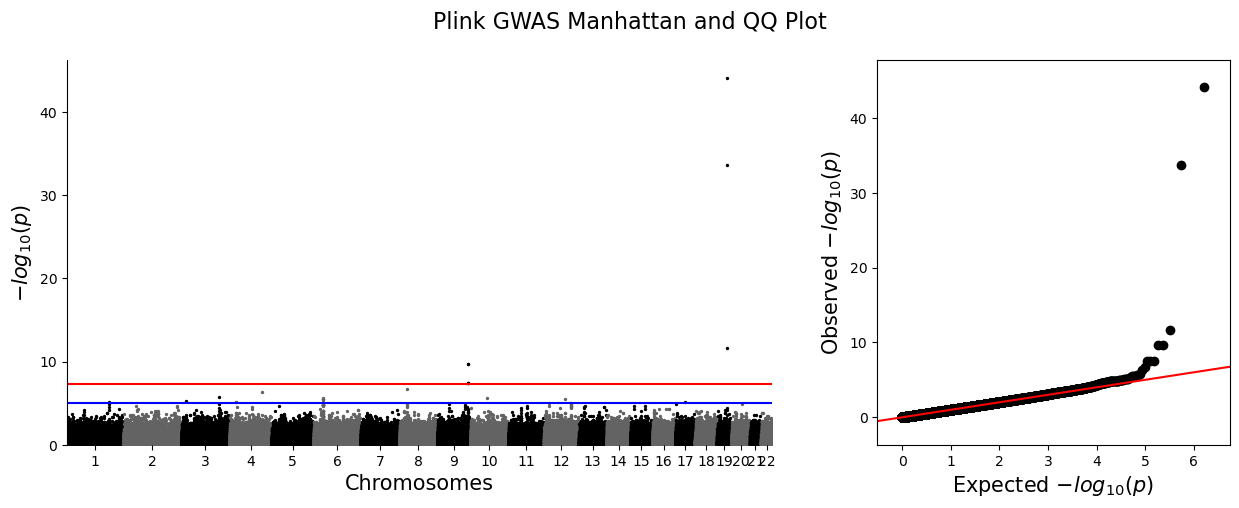

In [9]:
plink = pd.read_csv("../plink_results/ps3_gwas_covar.assoc.linear", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("Plink GWAS Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(plink, ax=ax0)
qqman.qqplot(plink, ax=ax1)

### GWAS in Python Manhattan and QQ Plot

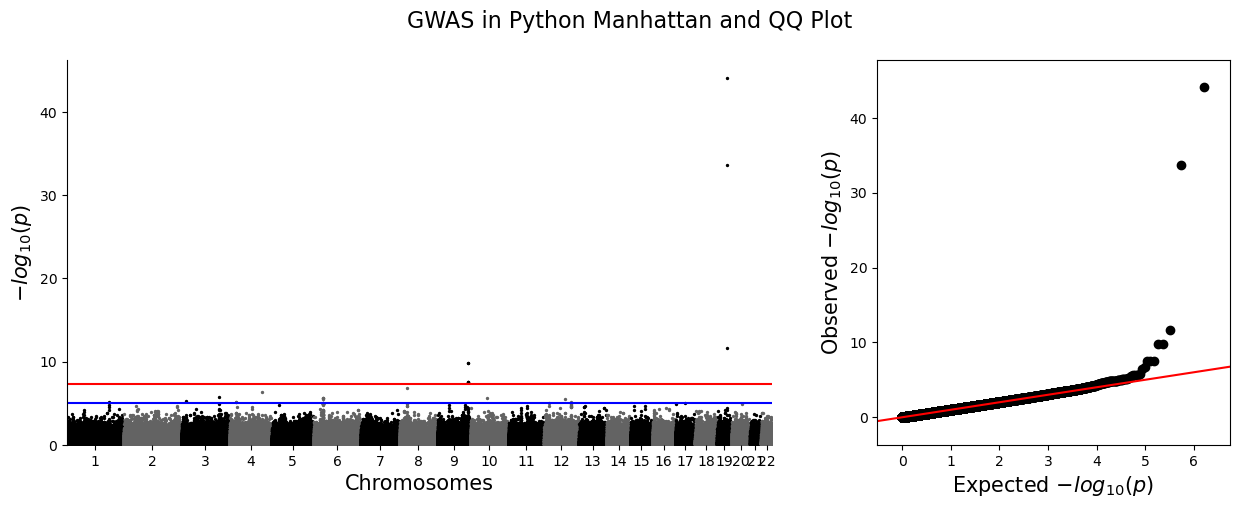

In [10]:
gwas_py = pd.read_csv("../python_results/gwas_results_covar.tsv", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("GWAS in Python Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(gwas_py, ax=ax0)
qqman.qqplot(gwas_py, ax=ax1)

### Effect Size Comparison

Beta correlation: 1.000


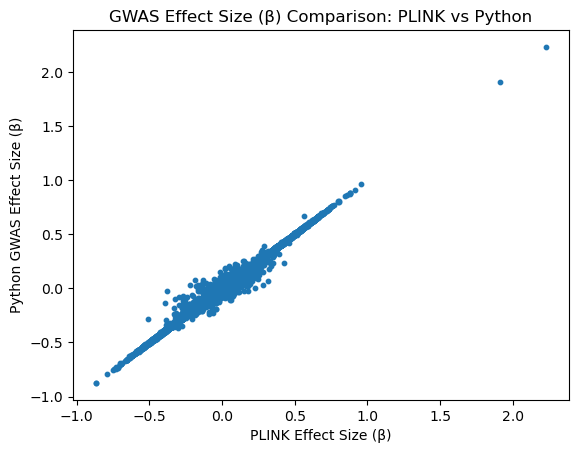

In [11]:
merged = plink.merge(gwas_py, on="SNP", suffixes=("_plink", "_gwas_py"))

corr = merged["BETA_plink"].corr(merged["BETA_gwas_py"])
print(f"Beta correlation: {corr:.3f}")

plt.scatter(merged["BETA_plink"], merged["BETA_gwas_py"], s=10)
plt.xlabel("PLINK Effect Size (β)")
plt.ylabel("Python GWAS Effect Size (β)")
plt.title("GWAS Effect Size (β) Comparison: PLINK vs Python")
plt.show()

### P-Value Comparison

P-value correlation: 0.999


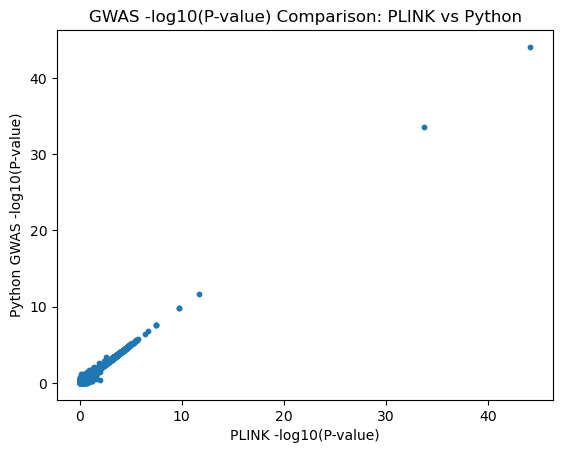

In [12]:
merged["logP_plink"] = -np.log10(merged["P_plink"])
merged["logP_gwas_py"] = -np.log10(merged["P_gwas_py"])

corr = merged["P_plink"].corr(merged["P_gwas_py"])
print(f"P-value correlation: {corr:.3f}")

plt.scatter(merged["logP_plink"], merged["logP_gwas_py"], s=10)
plt.xlabel("PLINK -log10(P-value)")
plt.ylabel("Python GWAS -log10(P-value)")
plt.title("GWAS -log10(P-value) Comparison: PLINK vs Python")
plt.show()

In [13]:
merged["rank_plink"] = merged["P_plink"].rank(method="min")
merged["rank_gwas_py"]  = merged["P_gwas_py"].rank(method="min")

merged[["rank_plink", "rank_gwas_py"]].corr()

top_plink = set(plink.nsmallest(10, "P")["SNP"])
top_gwas_py  = set(gwas_py.nsmallest(10, "P")["SNP"])

print("Overlap in Top 10:", len(top_plink & top_gwas_py))

Overlap in Top 10: 10


In [14]:
summary = merged[[
    "SNP",
    "BETA_plink", "BETA_gwas_py",
    "P_plink", "P_gwas_py",
    "rank_plink", "rank_gwas_py"
]].sort_values("rank_plink").head(20)

summary

,SNP,BETA_plink,BETA_gwas_py,P_plink,P_gwas_py,rank_plink,rank_gwas_py
302263,rs62117204,2.2320,2.232244,7.782000e-45,8.170536e-45,1.0,1.0
302266,rs4803750,1.9110,1.910680,2.122000e-34,2.294679e-34,2.0,2.0
302262,rs1531517,0.8782,0.878578,2.279000e-12,2.256419e-12,3.0,3.0
833754,rs507666,-0.8700,-0.873846,2.024000e-10,1.640214e-10,4.0,4.0
833752,rs2519093,-0.8700,-0.873846,2.024000e-10,1.640214e-10,4.0,4.0
833761,rs495828,-0.6946,-0.698511,3.333000e-08,2.730954e-08,6.0,6.0
833759,rs651007,-0.6946,-0.698511,3.333000e-08,2.730954e-08,6.0,6.0
833760,rs579459,-0.6946,-0.698511,3.333000e-08,2.730954e-08,6.0,6.0
759797,rs962040,0.6920,0.694285,1.900000e-07,1.736315e-07,9.0,9.0
588158,rs3804100,0.8599,0.861290,4.352000e-07,4.194258e-07,10.0,10.0


# Clumping Comparisons

## Helper Functions

In [15]:
# Parse SP2 columns
def clean_sp2_plink(x):
    if x == "NONE":
        return np.nan
    snps = x.split(",")
    return [re.sub(r"\(.*?\)", "", s) for s in snps]

def clean_sp2_py(x):
    if pd.isna(x):
        return x
    return x.split(",")

In [16]:
# Make clump sets for Jaccard
def make_clump_set(row):
    members = row["SP2_clean"]

    if isinstance(members, (list, tuple, set)):
        members = list(members)
    else:
        members = []   # handles NaN or anything unexpected

    return frozenset([row["SNP"]] + members)

## No Covariance

In [17]:
plink = pd.read_csv('../plink_results/ps3_gwas_clump.clumped', sep=r"\s+")
plink["SP2_clean"] = plink["SP2"].apply(clean_sp2_plink)

gwas_py = pd.read_csv('../python_results/gwas_results_clumped.tsv', sep="\t")
gwas_py["SP2_clean"] = gwas_py["SP2"].apply(clean_sp2_py)

In [18]:
# Compare index SNPs
plink_index = set(plink['SNP'])
mine_index = set(gwas_py['SNP'])

print(f"PLINK index SNPs: {len(plink_index)}")
print(f"My index SNPs:    {len(mine_index)}")
print(f"Shared:           {len(plink_index & mine_index)}")
print(f"Only in PLINK:    {len(plink_index - mine_index)}")
print(f"Only in mine:     {len(mine_index - plink_index)}")

jaccard = len(plink_index & mine_index) / len(plink_index | mine_index)
print(f"Lead Jaccard: {jaccard:.4f}")

PLINK index SNPs: 222
My index SNPs:    217
Shared:           212
Only in PLINK:    10
Only in mine:     5
Lead Jaccard: 0.9339


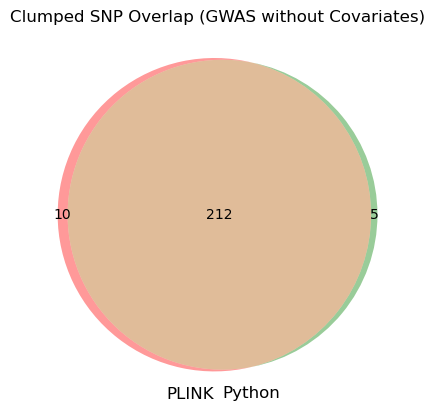

In [19]:
plt.figure()
venn2([plink_index, mine_index], set_labels=("PLINK", "Python"))
plt.title("Clumped SNP Overlap (GWAS without Covariates)")
plt.show()

In [20]:
plink_clumps = set(plink.apply(make_clump_set, axis=1))
mine_clumps  = set(gwas_py.apply(make_clump_set, axis=1))

plink_all = set().union(*plink_clumps)
mine_all  = set().union(*mine_clumps)

jaccard = len(plink_all & mine_all) / len(plink_all | mine_all)
print("SNP-level Jaccard:", jaccard)

SNP-level Jaccard: 0.6957950065703022


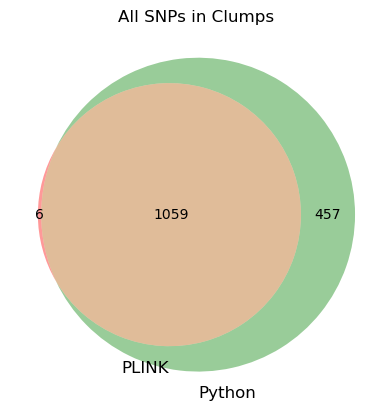

In [21]:
plt.figure()
venn2([plink_all, mine_all], set_labels=("PLINK", "Python"))
plt.title("All SNPs in Clumps")
plt.show()

# Covariance

In [22]:
plink = pd.read_csv('../plink_results/ps3_gwas_covar_clump.clumped', sep=r"\s+")
plink["SP2_clean"] = plink["SP2"].apply(clean_sp2_plink)

gwas_py = pd.read_csv('../python_results/gwas_results_covar_clumped.tsv', sep="\t")
gwas_py["SP2_clean"] = gwas_py["SP2"].apply(clean_sp2_py)

In [23]:
# Compare index SNPs
plink_index = set(plink['SNP'])
mine_index = set(gwas_py['SNP'])

print(f"PLINK index SNPs: {len(plink_index)}")
print(f"My index SNPs:    {len(mine_index)}")
print(f"Shared:           {len(plink_index & mine_index)}")
print(f"Only in PLINK:    {len(plink_index - mine_index)}")
print(f"Only in mine:     {len(mine_index - plink_index)}")

jaccard = len(plink_index & mine_index) / len(plink_index | mine_index)
print(f"Jaccard index: {jaccard:.4f}")

PLINK index SNPs: 3
My index SNPs:    3
Shared:           2
Only in PLINK:    1
Only in mine:     1
Jaccard index: 0.5000


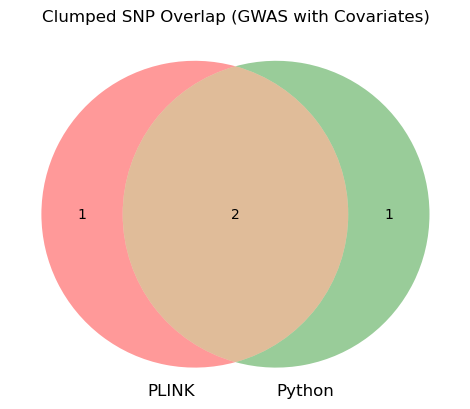

In [24]:
plt.figure()
venn2([plink_index, mine_index], set_labels=("PLINK", "Python"))
plt.title("Clumped SNP Overlap (GWAS with Covariates)")
plt.show()

In [25]:
plink_clumps = set(plink.apply(make_clump_set, axis=1))
mine_clumps  = set(gwas_py.apply(make_clump_set, axis=1))

plink_all = set().union(*plink_clumps)
mine_all  = set().union(*mine_clumps)

jaccard = len(plink_all & mine_all) / len(plink_all | mine_all)
print("SNP-level Jaccard:", jaccard)

SNP-level Jaccard: 1.0


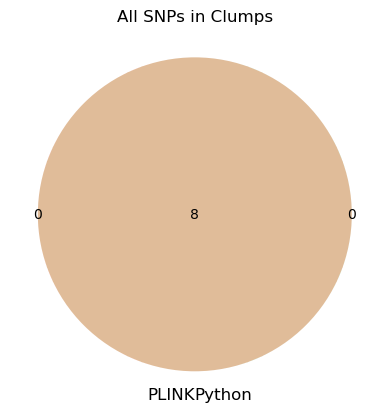

In [26]:
plt.figure()
venn2([plink_all, mine_all], set_labels=("PLINK", "Python"))
plt.title("All SNPs in Clumps")
plt.show()